In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt
import numpy as np

In [23]:
# Load
df = pd.read_csv("cancer.csv")

X = df.drop(columns=["Class"])
y = df["Class"]
X[:6],y[:6]

(   age  menopause  tumor-size  inv-nodes  node-caps  deg-malig  breast  \
 0    5          1           1          1          2          1       3   
 1    5          4           4          5          7         10       3   
 2    3          1           1          1          2          2       3   
 3    6          8           8          1          3          4       3   
 4    4          1           1          3          2          1       3   
 5    8         10          10          8          7         10       9   
 
    breast-quad  irradiat  
 0            1         1  
 1            2         1  
 2            1         1  
 3            7         1  
 4            1         1  
 5            7         1  ,
 0    0
 1    0
 2    0
 3    0
 4    0
 5    1
 Name: Class, dtype: int64)

In [24]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [25]:
# Models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Linear Regression": LinearRegression(),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [26]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    if name == "Linear Regression":
        scores = model.predict(X_test)
        y_pred = (scores >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        scores = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, scores)
    })

results_df = pd.DataFrame(results).sort_values(
    "Accuracy", ascending=False
)

print(results_df.to_string(index=False))



              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.963504   0.921569 0.979167 0.949495 0.992041
           Boosting  0.963504   0.921569 0.979167 0.949495 0.988062
                KNN  0.956204   0.920000 0.958333 0.938776 0.977060
            Bagging  0.956204   0.920000 0.958333 0.938776 0.983731
  Linear Regression  0.941606   0.916667 0.916667 0.916667 0.992041


In [27]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Class 0", "Class 1"],
        digits=4
    )
)

              precision    recall  f1-score   support

     Class 0     0.9884    0.9551    0.9714        89
     Class 1     0.9216    0.9792    0.9495        48

    accuracy                         0.9635       137
   macro avg     0.9550    0.9671    0.9605       137
weighted avg     0.9650    0.9635    0.9637       137



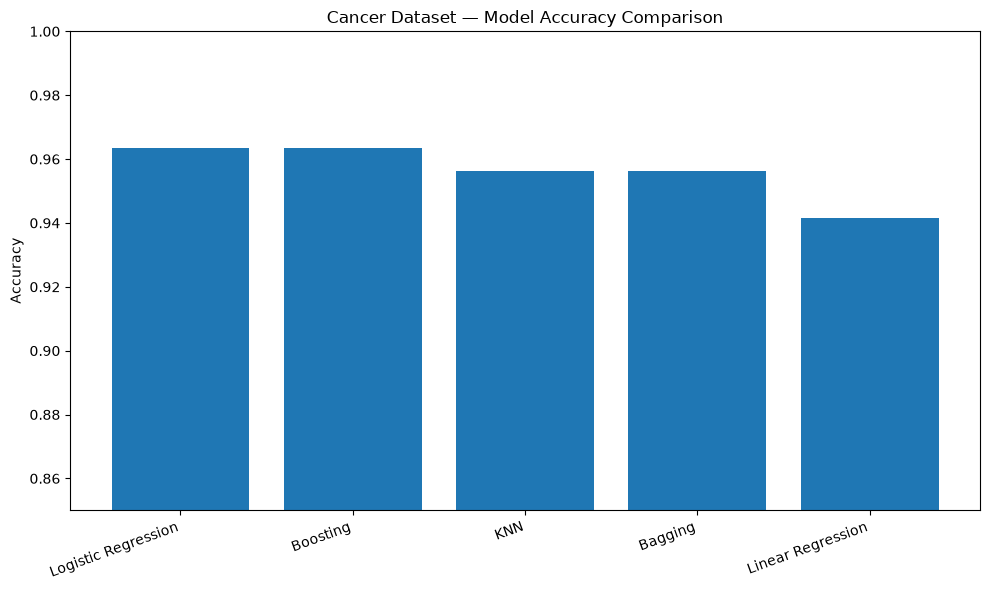

In [28]:
# Accuracy plot
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylim(0.85, 1.0)
plt.ylabel("Accuracy")
plt.title("Cancer Dataset — Model Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

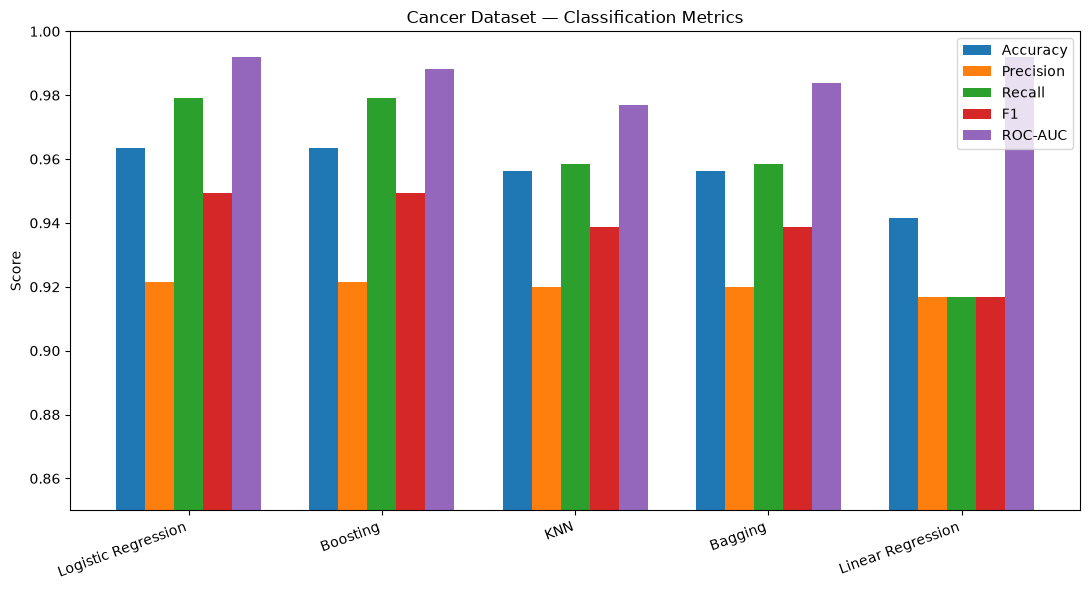

In [29]:
# Metrics plot
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(results_df))
width = 0.15

plt.figure(figsize=(11, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 2) * width, results_df[metric], width, label=metric)

plt.xticks(x, results_df["Model"], rotation=20, ha="right")
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.title("Cancer Dataset — Classification Metrics")
plt.legend()
plt.tight_layout()
plt.show()

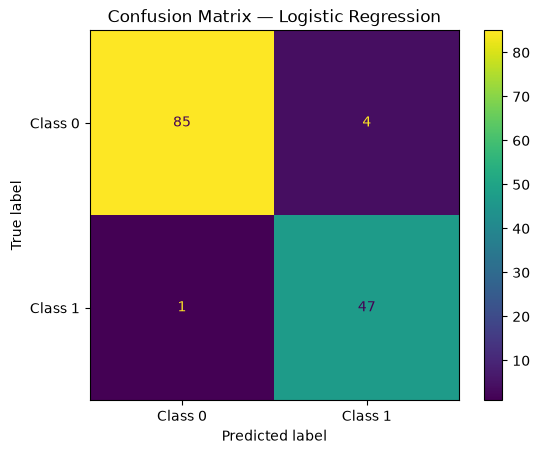

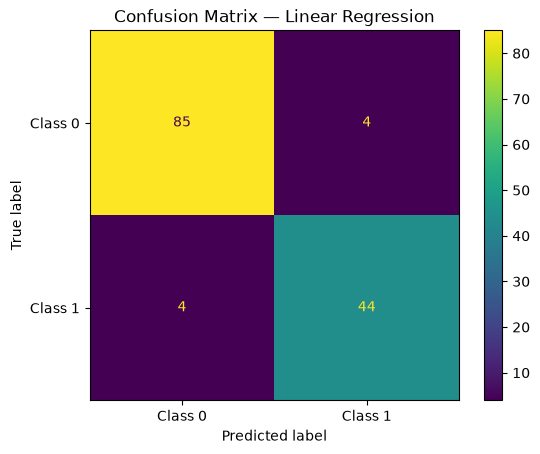

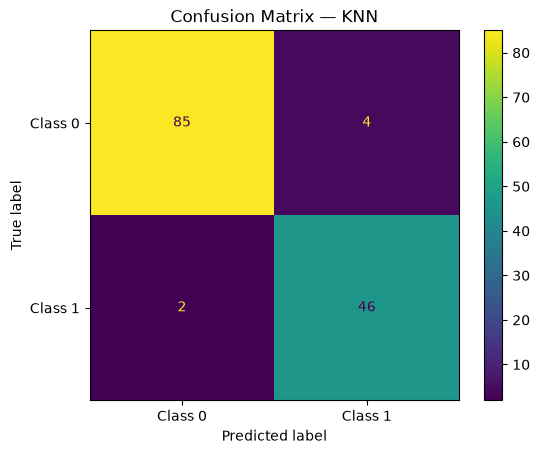

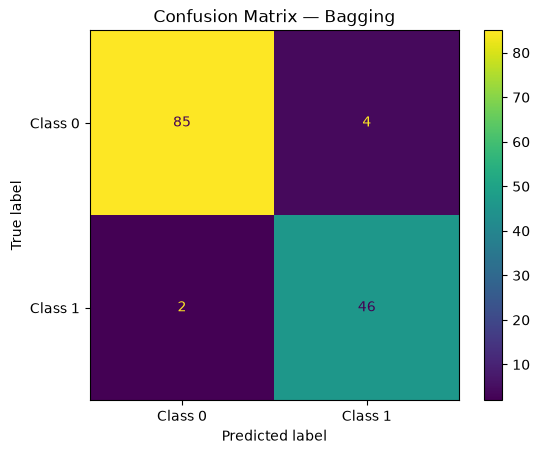

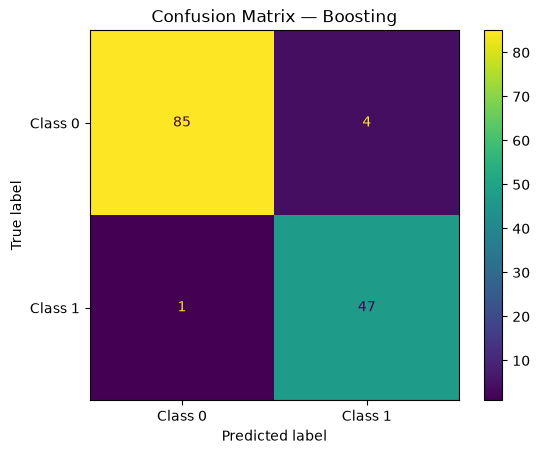

In [30]:
# Confusion matrices
for name in models:
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Class 0", "Class 1"]
    ).plot(values_format="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()